In [2]:
import anndata
import scanpy as sc
from sklearn import metrics
import matplotlib as mpl
from matplotlib import pyplot as plt
import numpy as np
import plotly.express as px

adata = anndata.read_h5ad(filename='/home/fahad/WS/ST/SEDIST/151673/151673_6379.h5ad')


In [3]:
print(adata)


AnnData object with n_obs × n_vars = 3611 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'imagecol', 'imagerow', 'slices_path', 'Ground_Truth', 'mclust'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'ARI', 'Ground_Truth_colors', 'hvg', 'log1p', 'mclust_colors', 'neighbors', 'spatial'
    obsm: 'adj', 'combined_feat', 'distance_matrix', 'emb', 'emb_pca', 'feat_a', 'graph_neigh', 'image_feat', 'label_CSL', 'spatial'
    obsp: 'connectivities', 'distances'


/home/fahad/WS/ST/stenv/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/fahad/WS/ST/stenv/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)



Cluster 1 (Colormap: magma) Top Genes: ['MBP', 'PLP1', 'CRYAB', 'CNP', 'MOBP']

Cluster 2 (Colormap: magma) Top Genes: ['MBP', 'DIRAS2', 'PLP1', 'KRT17', 'SLC17A7']

Cluster 3 (Colormap: magma) Top Genes: ['NEFL', 'NEFM', 'YWHAH', 'SNCG', 'NRGN']

Cluster 4 (Colormap: magma) Top Genes: ['MALAT1', 'CLU', 'CST3', 'COX6C', 'SLC1A2']

Cluster 5 (Colormap: magma) Top Genes: ['IGKC', 'IGLC2', 'IGHG3', 'SCGB1D2', 'SCGB2A2']

Cluster 6 (Colormap: magma) Top Genes: ['CAMK2N1', 'HPCAL1', 'ENC1', 'HOPX', 'SERPINE2']

Cluster 7 (Colormap: magma) Top Genes: ['TMSB10', 'PCP4', 'SNAP25', 'TUBA1B', 'TUBB2A']


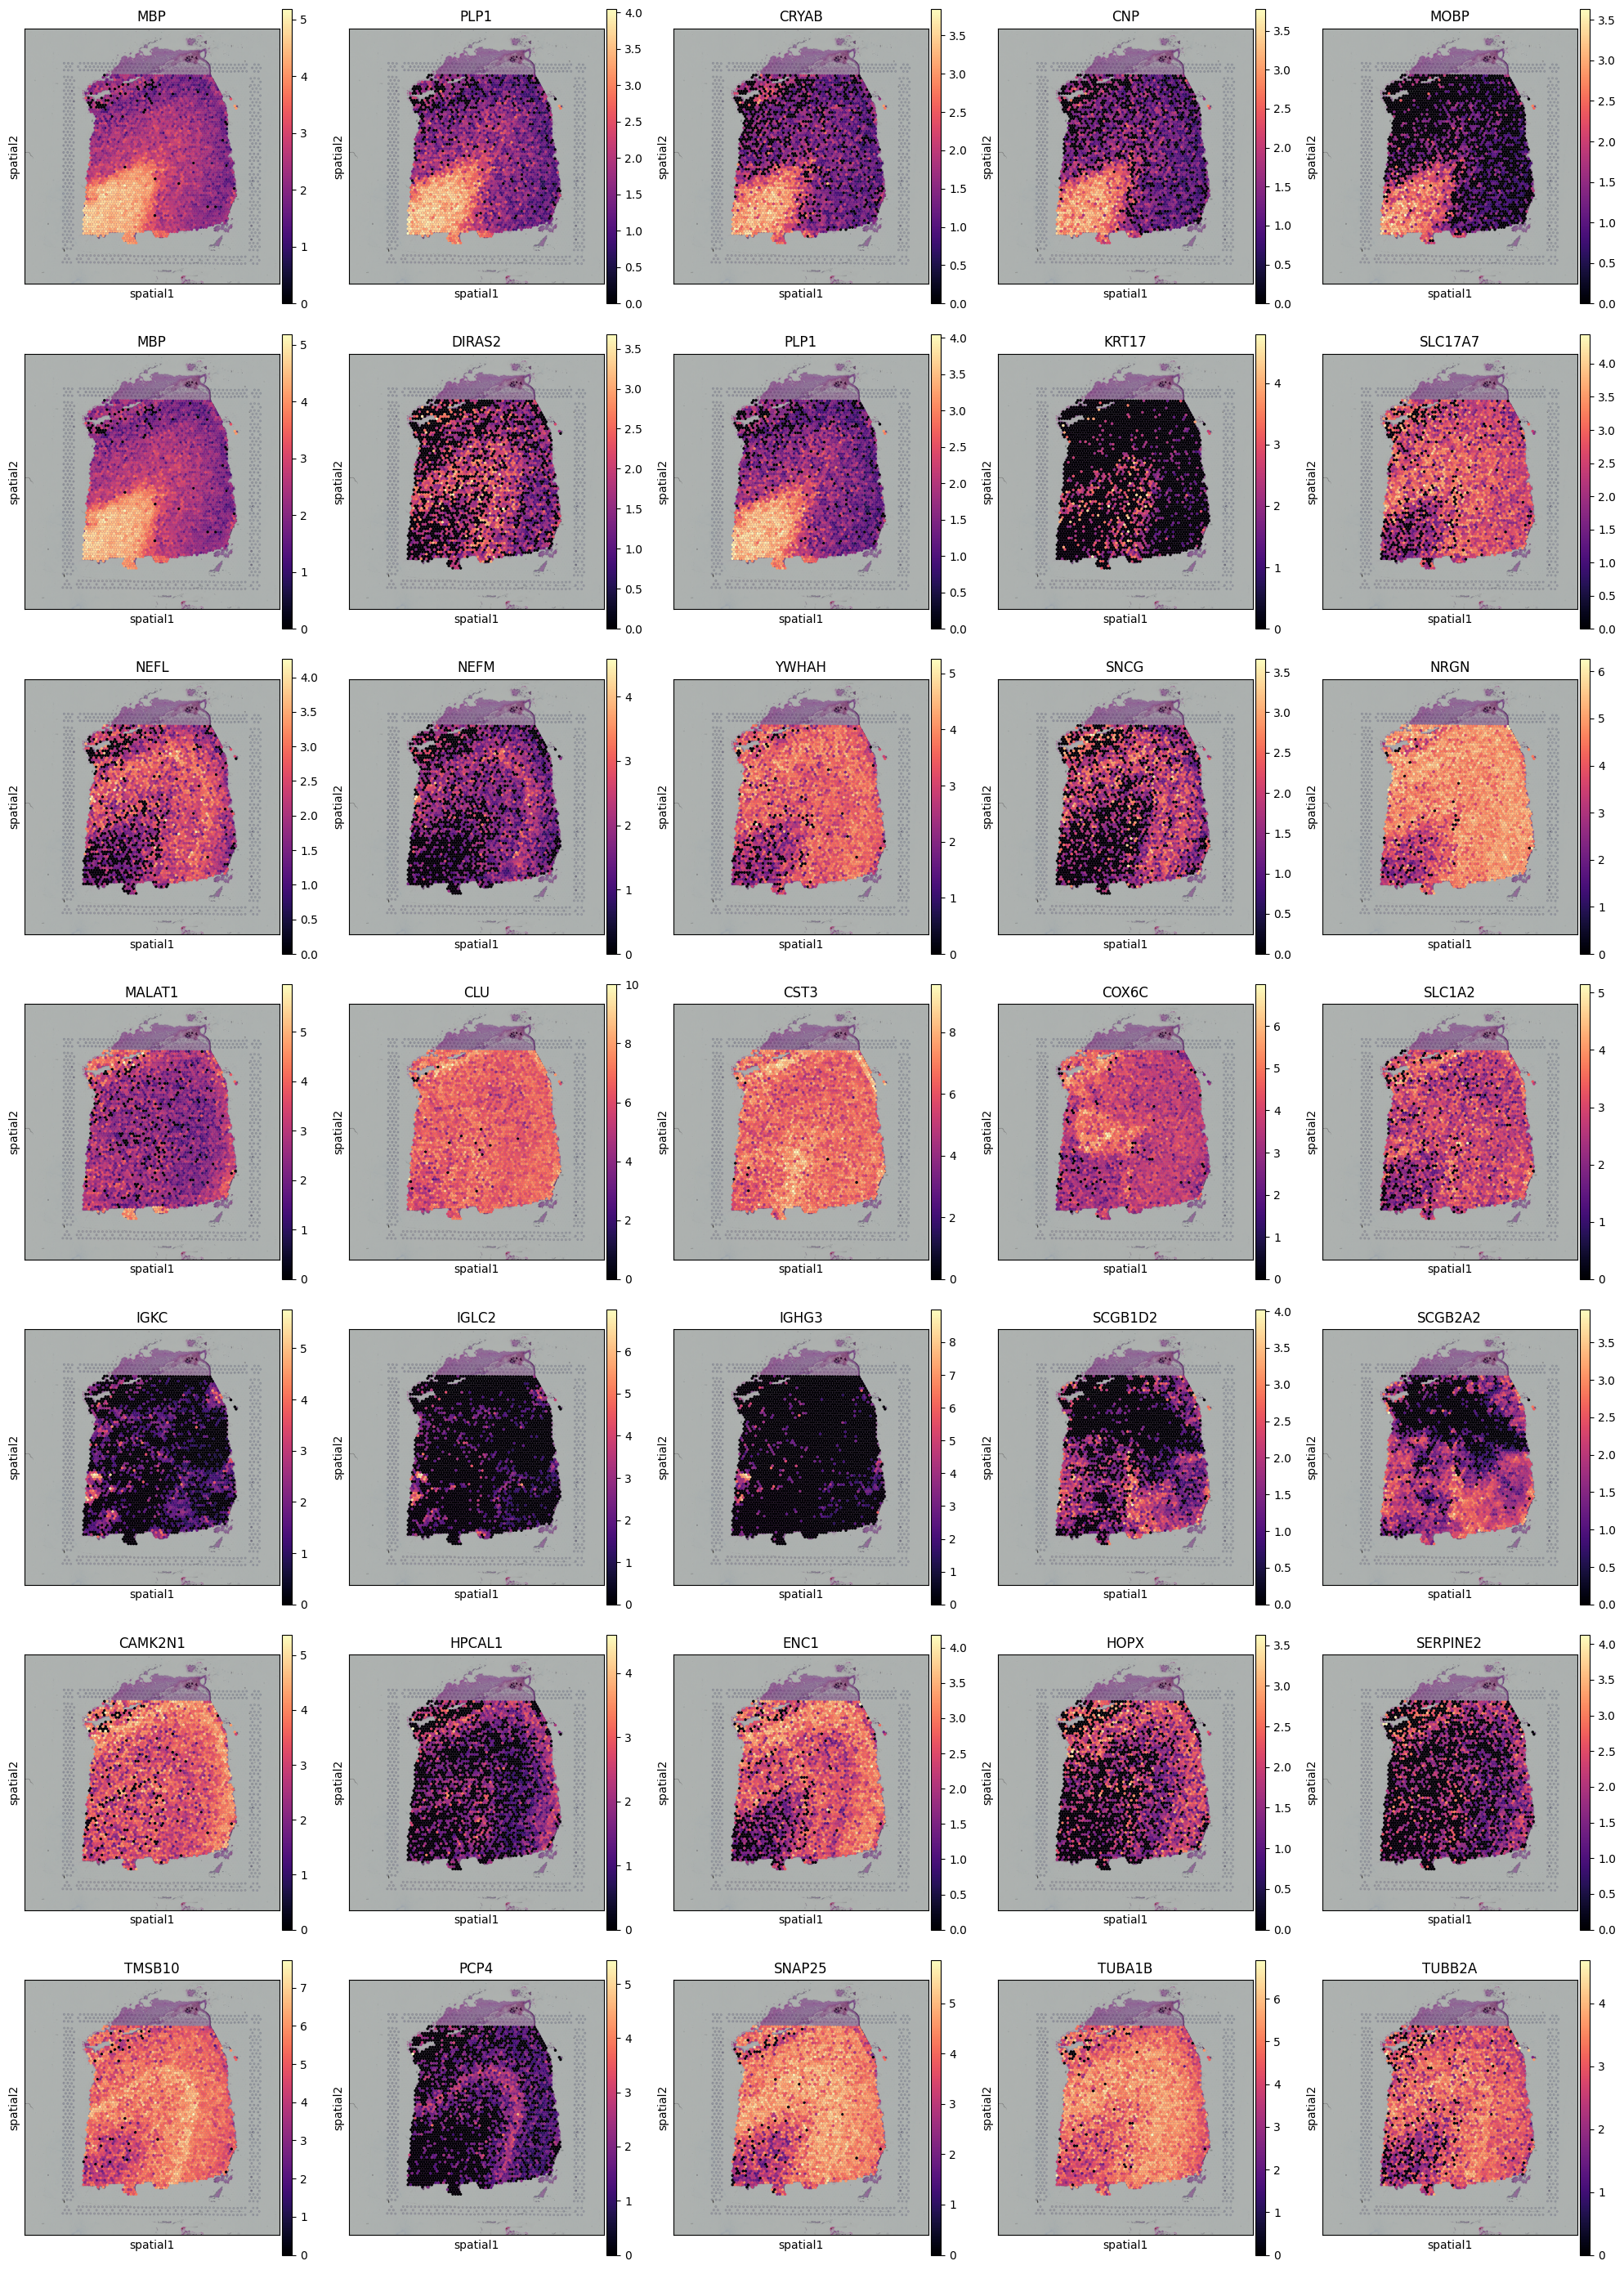

<Figure size 640x480 with 0 Axes>

In [ ]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
from itertools import cycle

sc.tl.rank_genes_groups(adata, groupby="mclust", method="wilcoxon")

result = adata.uns['rank_genes_groups']
groups = list(result['names'].dtype.names)

top_genes = {
    group: result['names'][group][:5].tolist()
    for group in groups
}

n_rows = len(groups)
n_cols = 5
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))

if n_rows == 1:
    axs = [axs]

for row_idx, group in enumerate(groups):
    genes = top_genes[group]
    cmap = 'magma'

    print(f"\nCluster {group} (Colormap: {cmap}) Top Genes: {genes}")
    
    cluster_layer_col = 'mclust'
    layers = adata.obs[cluster_layer_col].unique()

    layer_cycle = cycle(layers)
    for col_idx, gene in enumerate(genes):
        ax = axs[row_idx][col_idx] if n_rows > 1 else axs[col_idx]
        if gene in adata.var_names:
            layer = next(layer_cycle)
            sq.pl.spatial_scatter(
                adata,
                color=gene,
                ax=ax,
                title=f"{gene}",
                size=1.5,
                cmap=cmap
            )
        else:
            ax.axis('off')
            ax.set_title(f"{gene} not found")

plt.tight_layout()
plt.show()
plt.savefig('top_5_genes_per_cluster(magma).png', dpi=3000, bbox_inches='tight')


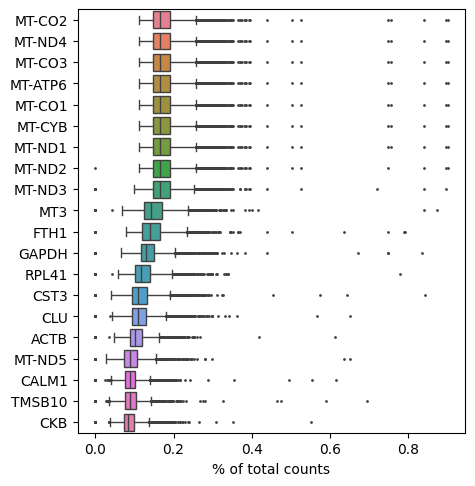

In [8]:

sc.pl.highest_expr_genes(adata, n_top=20)


In [9]:
cell_index = 0
gene_expression = adata.X[cell_index]
expressed_gene_indices = gene_expression.nonzero()[1]
expressed_genes = adata.var_names[expressed_gene_indices]
print(expressed_genes)

Index(['HES4', 'AGRN', 'C1orf159', 'SDF4', 'UBE2J2', 'ACAP3', 'CPTP', 'VWA1',
       'SSU72', 'MMP23B',
       ...
       'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4',
       'MT-ND5', 'MT-ND6', 'MT-CYB'],
      dtype='object', length=3586)


In [12]:
gene_counts_sum = np.sum(adata.X, axis=0)
gene_with_most_counts = adata.var_names[np.argmax(gene_counts_sum)]
print("Gene with the most counts:", gene_with_most_counts)

Gene with the most counts: MT-CO1


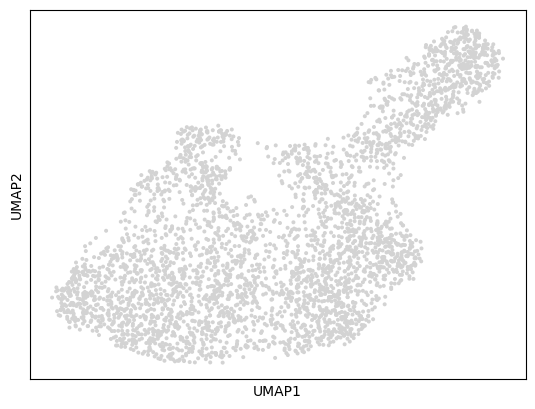

In [13]:
sc.tl.umap(adata, n_components=2)
sc.pl.umap(adata)

In [14]:
sc.tl.diffmap(adata)


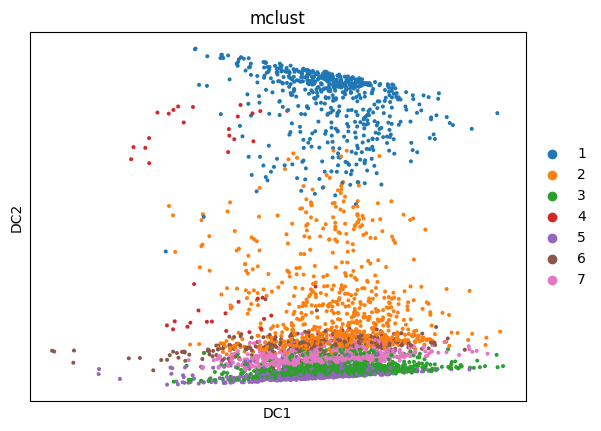

In [15]:
sc.pl.diffmap(adata, color='mclust')


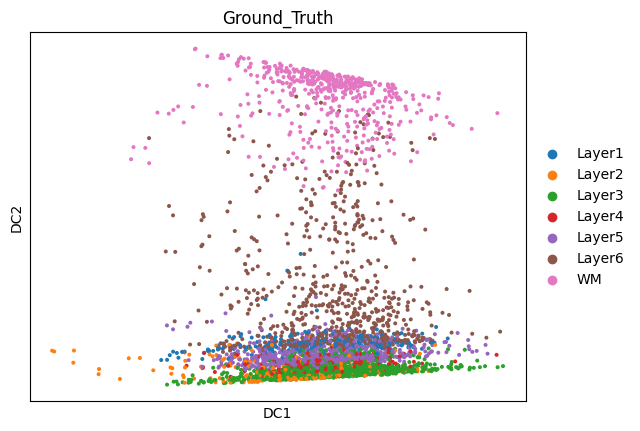

In [16]:
sc.pl.diffmap(adata, color='Ground_Truth')


In [17]:
sc.tl.draw_graph(adata)


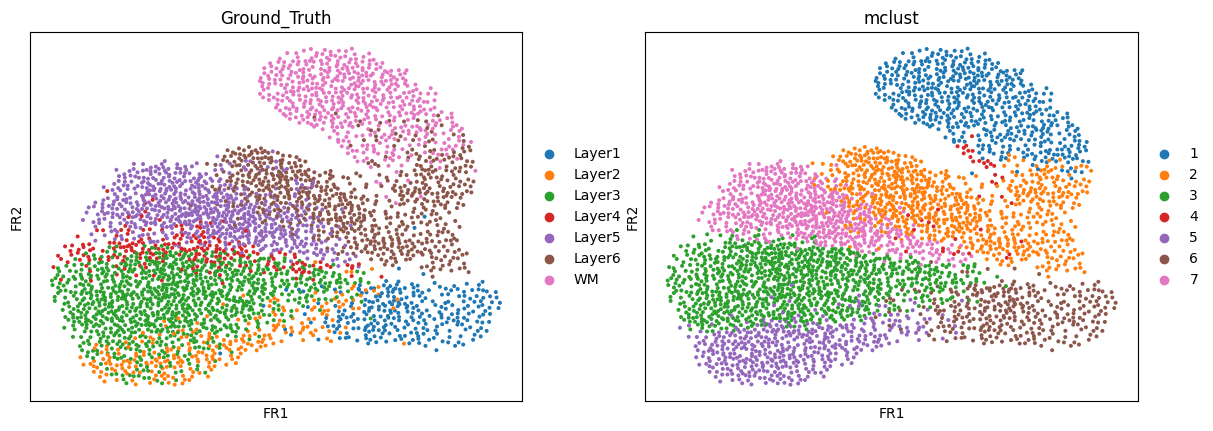

In [18]:
sc.pl.draw_graph(adata, color=['Ground_Truth', 'mclust'])


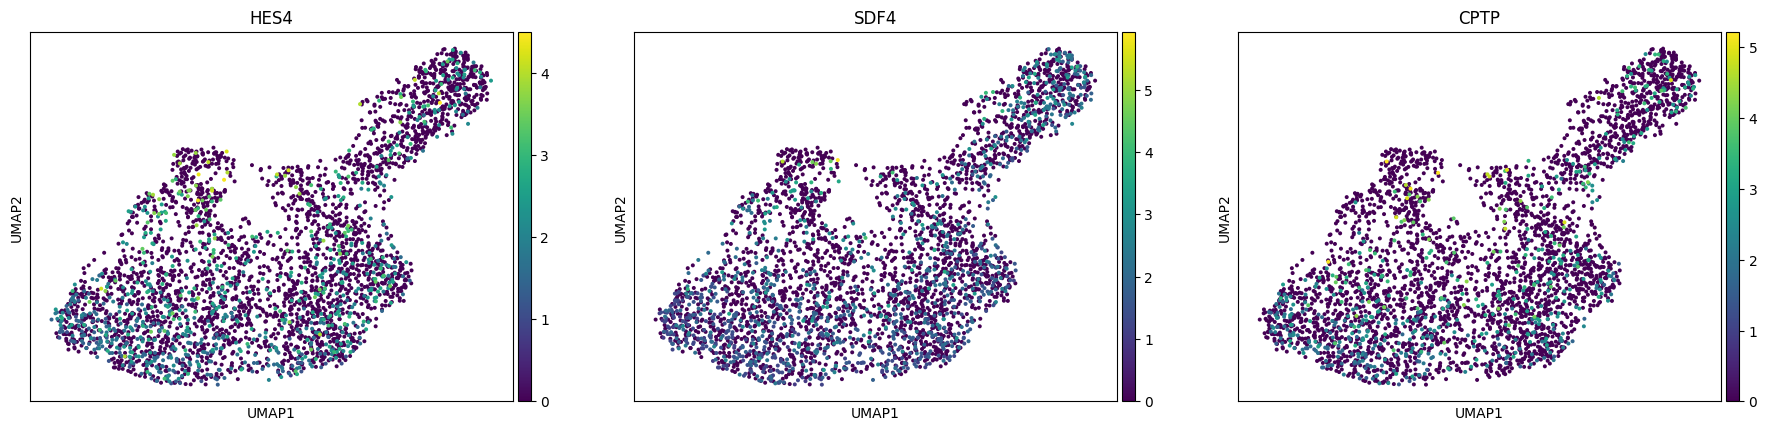

In [19]:
sc.pl.umap(adata, color=["HES4", "SDF4", "CPTP"])


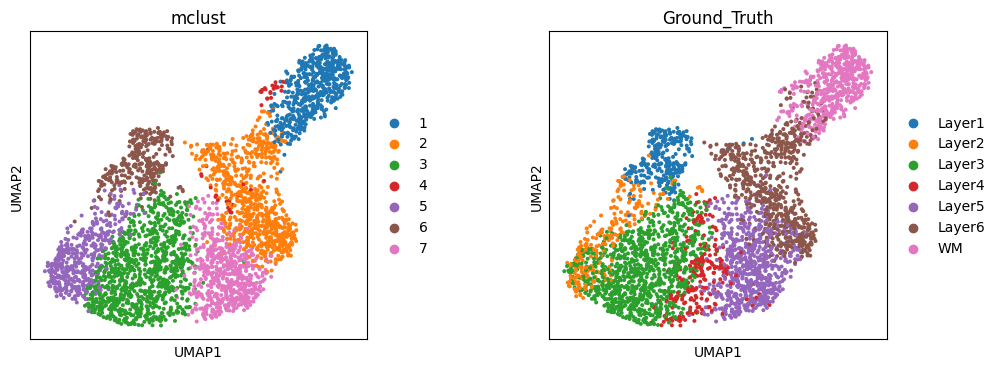

In [20]:

plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(adata, color=["mclust","Ground_Truth"], wspace=0.4)

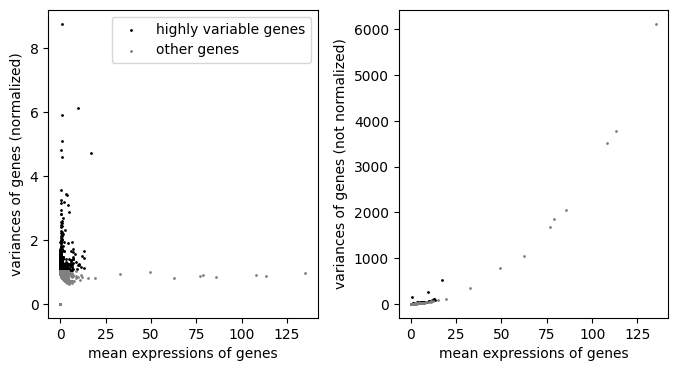

In [21]:
sc.pl.highly_variable_genes(adata)


In [22]:
sc.pp.pca(adata)

In [23]:
sc.tl.rank_genes_groups(adata, "mclust", method="t-test")

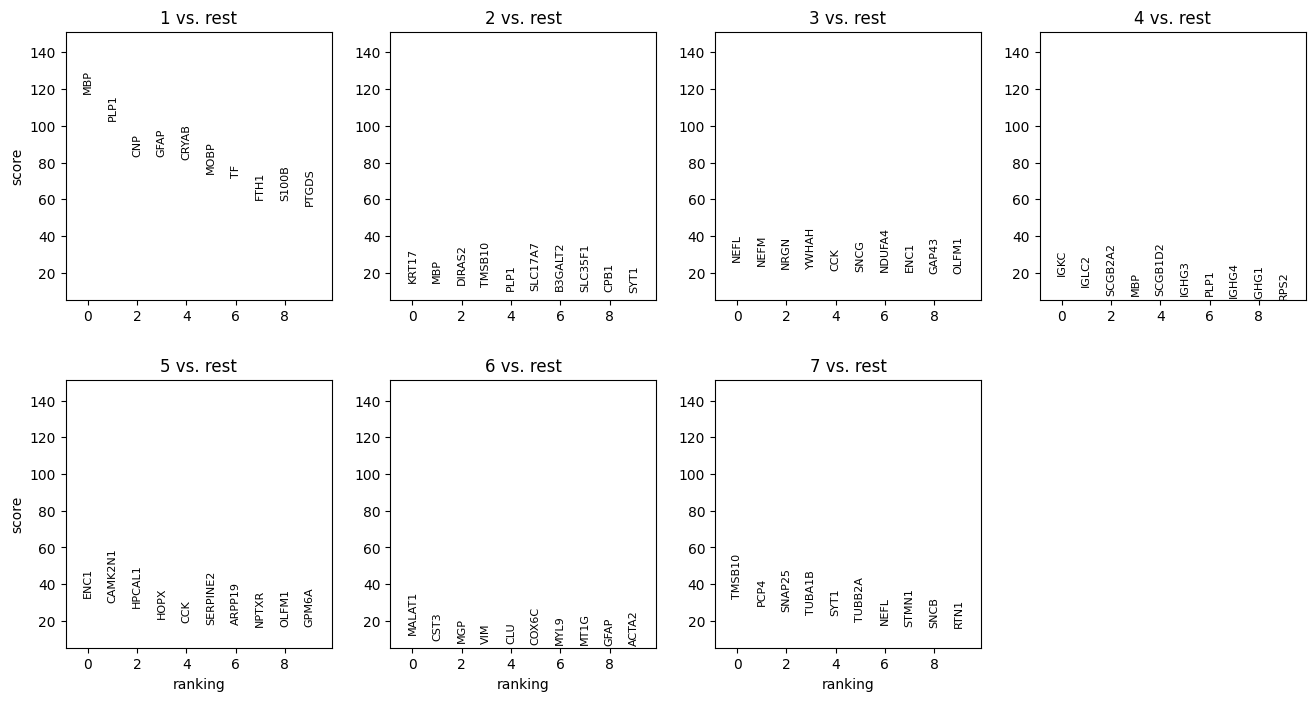

In [24]:
sc.pl.rank_genes_groups(adata, n_genes=10)


In [25]:
result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names
top_features = {}
n_top_genes = 10
for group in groups:
    top_features[group] = result["names"][group][:n_top_genes]

for group, features in top_features.items():
    print(f"Cluster {group} top features:")
    for feature in features:
        print(feature)
    print()

Cluster 1 top features:
MBP
PLP1
CNP
GFAP
CRYAB
MOBP
TF
FTH1
S100B
PTGDS

Cluster 2 top features:
KRT17
MBP
DIRAS2
TMSB10
PLP1
SLC17A7
B3GALT2
SLC35F1
CPB1
SYT1

Cluster 3 top features:
NEFL
NEFM
NRGN
YWHAH
CCK
SNCG
NDUFA4
ENC1
GAP43
OLFM1

Cluster 4 top features:
IGKC
IGLC2
SCGB2A2
MBP
SCGB1D2
IGHG3
PLP1
IGHG4
IGHG1
RPS2

Cluster 5 top features:
ENC1
CAMK2N1
HPCAL1
HOPX
CCK
SERPINE2
ARPP19
NPTXR
OLFM1
GPM6A

Cluster 6 top features:
MALAT1
CST3
MGP
VIM
CLU
COX6C
MYL9
MT1G
GFAP
ACTA2

Cluster 7 top features:
TMSB10
PCP4
SNAP25
TUBA1B
SYT1
TUBB2A
NEFL
STMN1
SNCB
RTN1



In [26]:

embedding = adata.obsm['emb_pca']
mclust_labels = adata.obs["mclust"]

fig = px.scatter_3d(
    embedding,
    x=0,
    y=1,
    z=2,
    color=mclust_labels,
    title="3D Embedding with GENESPAT",
)

fig.show()


In [27]:

embedding = adata.obsm['emb_pca']
mclust_labels = adata.obs["Ground_Truth"]

fig = px.scatter_3d(
    embedding,
    x=0,
    y=1,
    z=2,
    color=mclust_labels,
    title="3D Embedding with Ground Truth Clustering",
)

fig.show()


In [28]:
import plotly.express as px
from kaleido.scopes.plotly import PlotlyScope

embedding = adata.obsm['emb_pca']
mclust_labels = adata.obs["mclust"]

fig = px.scatter_3d(
    embedding,
    x=0,
    y=1,
    z=2,
    color=mclust_labels,
    title="3D Embedding with GENESPAT",
)

fig.write_html("3d_embedding.html")

fig.show()

scope = PlotlyScope()
img_bytes = scope.transform(fig, format="png", width=800, height=600, scale=2.0)
with open("3d_embedding.png", "wb") as f:
    f.write(img_bytes)


In [29]:
ARI = metrics.adjusted_rand_score(adata.obs['mclust'], adata.obs['Ground_Truth'])
adata.uns['ARI'] = ARI
print('ARI:', ARI)

ARI: 0.6465748841155854


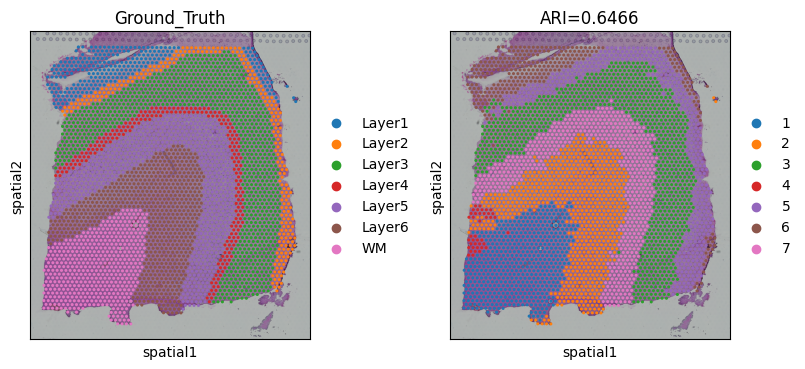

In [30]:
sc.pl.spatial(adata,
              img_key="hires",
              color=["Ground_Truth", "mclust"],
              title=["Ground_Truth", "ARI=%.4f"%ARI],
              show=True)

In [ ]:

plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(adata, color=["mclust","Ground_Truth"],title=['SEDIST (ARI=%.2f)'%ARI, "Ground Truth"], wspace=0.4)

In [32]:
used_adata = adata[adata.obs['Ground_Truth']!='nan',]
used_adata

View of AnnData object with n_obs × n_vars = 3611 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'imagecol', 'imagerow', 'slices_path', 'Ground_Truth', 'mclust'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'ARI', 'Ground_Truth_colors', 'hvg', 'log1p', 'mclust_colors', 'neighbors', 'spatial', 'umap', 'diffmap_evals', 'draw_graph', 'pca', 'rank_genes_groups'
    obsm: 'adj', 'combined_feat', 'distance_matrix', 'emb', 'emb_pca', 'feat_a', 'graph_neigh', 'image_feat', 'label_CSL', 'spatial', 'X_umap', 'X_diffmap', 'X_draw_graph_fr', 'X_pca'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'